# GraphRAG Experiment Analysis

Compare retrieval performance across different GraphRAG configurations.

**Metrics:**
- **Recall**: % of gold nodes retrieved
- **Precision**: % of retrieved entities that are relevant
- **F1**: Harmonic mean of Precision and Recall

In [35]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Style settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load comparison report
experiments_dir = Path('experiments')
report_path = experiments_dir / 'comparison_report.json'

if report_path.exists():
    with open(report_path) as f:
        report = json.load(f)
    print(f"Loaded {report['num_experiments']} experiments")
else:
    print("No comparison report found. Run experiments first:")
    print("  python create_evaluation_dataset.py --experiment <name>")
    print("  python evaluate_node_coverage.py --experiment <name>")
    print("  python compare_experiments.py")
    report = None

Loaded 11 experiments


In [36]:
# Build DataFrame from experiments
if report:
    rows = []
    for name, data in report['experiments'].items():
        overall = data.get('overall', {})
        config = data.get('config', {}).get('config', {})
        row = {
            'Experiment': name,
            'Recall': overall.get('avg_recall', 0) * 100,
            'Precision': overall.get('avg_precision', 0) * 100,
            'F1': overall.get('avg_f1', 0) * 100,
            'Avg Entities': overall.get('avg_key_entities', 0),
            'Samples': data.get('total_samples', 0),
            'Hybrid': config.get('enable_hybrid_retrieval', False),
            'CrossEncoder': config.get('enable_cross_encoder', False),
        }
        # Add hop-specific metrics
        for hop in ['0-hop', '1-hop', '2-hop']:
            hop_data = data.get('by_hop_count', {}).get(hop, {})
            row[f'{hop} F1'] = hop_data.get('avg_f1', 0) * 100
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values('F1', ascending=False)
    display(df[['Experiment', 'Recall', 'Precision', 'F1', 'Avg Entities']].round(2))

,Experiment,Recall,Precision,F1,Avg Entities
0,gemma_baseline,55.08,9.65,15.77,11.62
5,nomic_baseline,47.79,6.98,11.58,12.30
10,securebert_hybrid_cross_encoder,57.40,6.03,10.29,19.92
2,gemma_hybrid_cross_encoder,57.40,5.98,10.24,19.74
7,nomic_hybrid_cross_encoder,57.40,5.96,10.19,20.01
1,gemma_cross_encoder,45.25,5.93,9.90,16.70
8,securebert_baseline,37.75,5.38,8.98,12.89
6,nomic_cross_encoder,43.16,3.97,6.89,17.81
9,securebert_cross_encoder,37.97,3.92,6.65,18.62
4,gemma_ollama_cross_encoder,5.08,0.82,1.39,7.03


## Overall Metrics Comparison

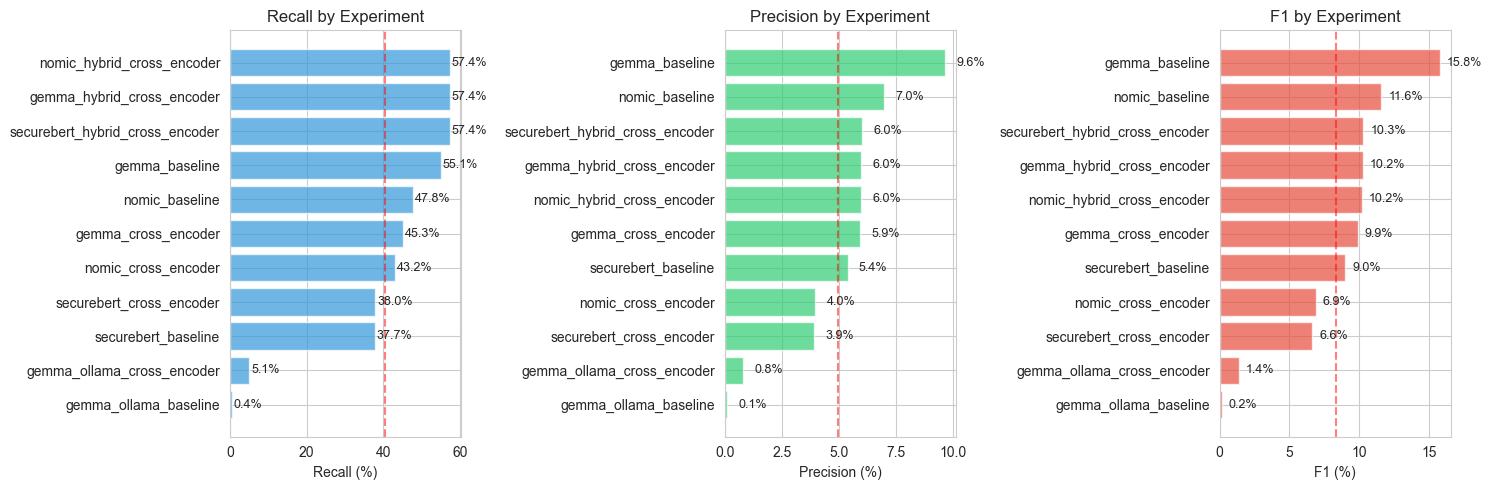

Saved: experiments/overall_comparison.png


In [37]:
if report and len(df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = ['Recall', 'Precision', 'F1']
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    for ax, metric, color in zip(axes, metrics, colors):
        data = df.sort_values(metric, ascending=True)
        ax.barh(data['Experiment'], data[metric], color=color, alpha=0.7)
        ax.set_xlabel(f'{metric} (%)')
        ax.set_title(f'{metric} by Experiment')
        ax.axvline(data[metric].mean(), color='red', linestyle='--', alpha=0.5, label='Mean')
        
        # Add value labels
        for i, v in enumerate(data[metric]):
            ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('experiments/overall_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: experiments/overall_comparison.png")

## Performance by Hop Count

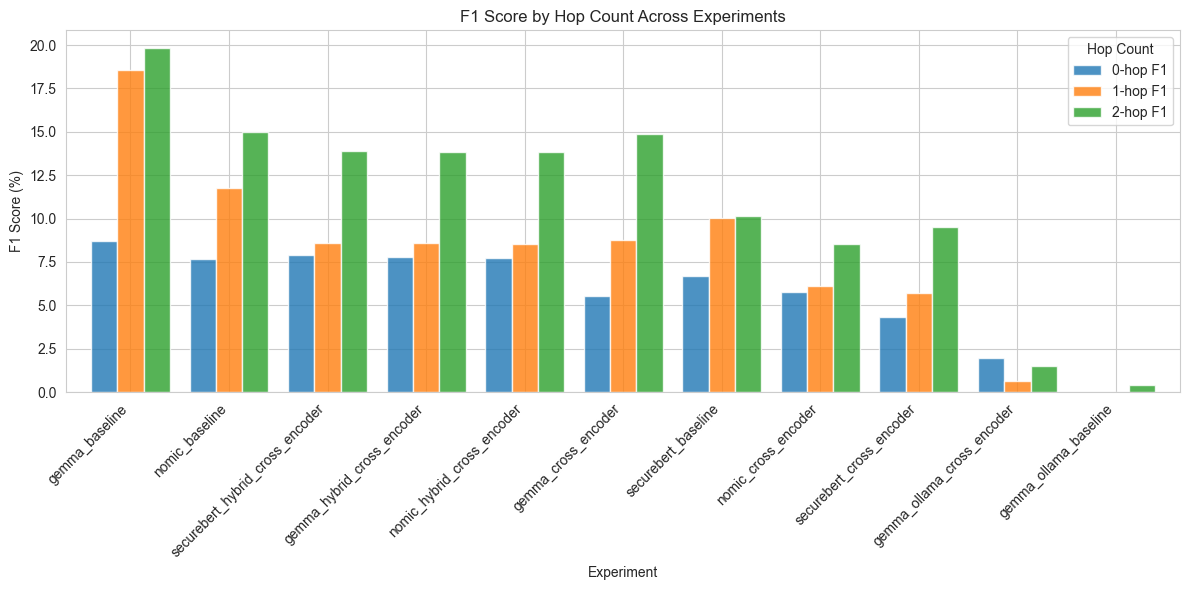

Saved: experiments/hop_comparison.png


In [38]:
if report and len(df) > 0:
    hop_cols = ['0-hop F1', '1-hop F1', '2-hop F1']
    hop_df = df[['Experiment'] + hop_cols].set_index('Experiment')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    hop_df.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)
    ax.set_ylabel('F1 Score (%)')
    ax.set_title('F1 Score by Hop Count Across Experiments')
    ax.legend(title='Hop Count')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('experiments/hop_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: experiments/hop_comparison.png")

## Precision vs Recall Trade-off

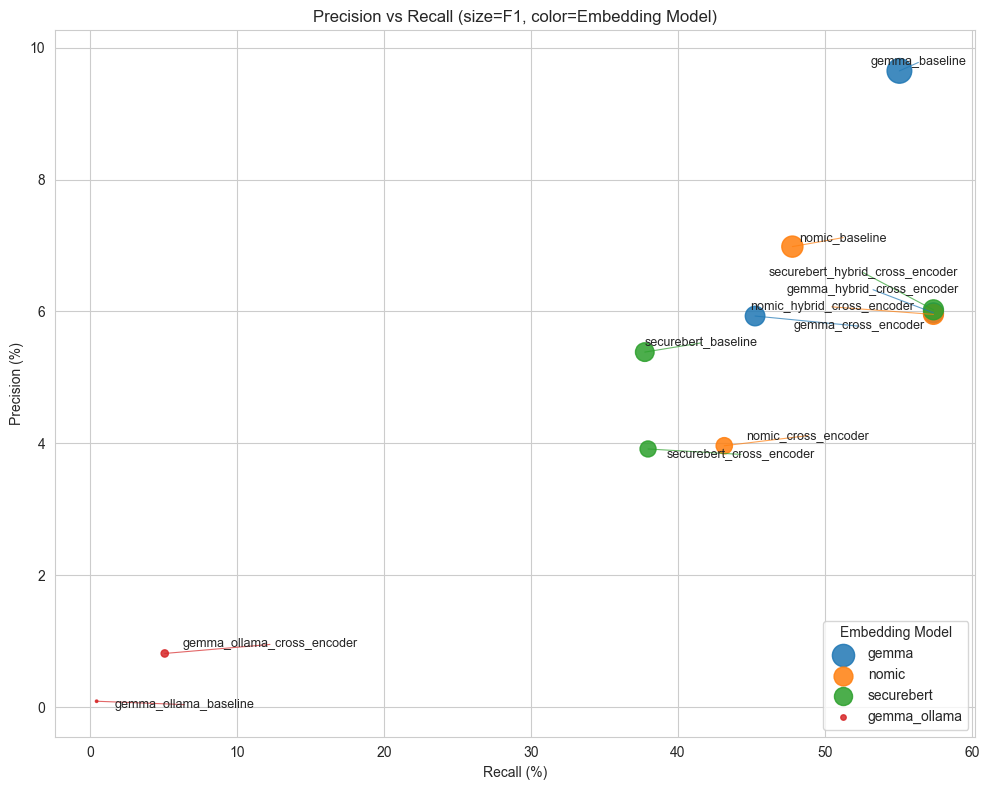

In [39]:
from adjustText import adjust_text
import seaborn as sns
import matplotlib.pyplot as plt

def extract_embedding_model(exp_name: str) -> str:
    name = exp_name.lower()
    if "nomic" in name:
        return "nomic"
    elif "securebert" in name:
        return "securebert"
    elif "gemma_ollama" in name or "ollama" in name:
        return "gemma_ollama"
    elif "gemma" in name:
        return "gemma"
    else:
        return "other"

# Create embedding model column from Experiment name
df["EmbeddingModel"] = df["Experiment"].apply(extract_embedding_model)

if report and len(df) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Categorical colors
    models = df["EmbeddingModel"].unique()
    palette = sns.color_palette("tab10", n_colors=len(models))
    color_map = dict(zip(models, palette))

    # Plot points
    for model in models:
        sub = df[df["EmbeddingModel"] == model]
        ax.scatter(
            sub["Recall"],
            sub["Precision"],
            s=sub["F1"] * 20,
            color=color_map[model],
            alpha=0.85,
            label=model
        )

    # Add text labels (no background)
    texts = []
    for _, row in df.iterrows():
        texts.append(
            ax.text(
                row["Recall"],
                row["Precision"],
                row["Experiment"],
                fontsize=9
            )
        )

    # Adjust labels to avoid overlap
    adjust_text(
        texts,
        ax=ax,
        expand_text=(1.2, 1.2),
        expand_points=(1.2, 1.2)
    )

    # Draw colored connector lines AFTER label adjustment
    for text, (_, row) in zip(texts, df.iterrows()):
        x_text, y_text = text.get_position()
        x_pt, y_pt = row["Recall"], row["Precision"]
        color = color_map[row["EmbeddingModel"]]

        ax.plot([x_pt, x_text], [y_pt, y_text], color=color, lw=0.8, alpha=0.7)

    ax.set_xlabel("Recall (%)")
    ax.set_ylabel("Precision (%)")
    ax.set_title("Precision vs Recall (size=F1, color=Embedding Model)")
    ax.legend(title="Embedding Model", loc="lower right", frameon=True)

    plt.tight_layout()
    plt.savefig("experiments/precision_recall_by_model_lines.png", dpi=150, bbox_inches="tight")
    plt.show()

## Key Insights

In [40]:
if report and len(df) > 0:
    print("=" * 60)
    print("KEY INSIGHTS")
    print("=" * 60)
    
    # Best performers
    best_recall = df.loc[df['Recall'].idxmax()]
    best_precision = df.loc[df['Precision'].idxmax()]
    best_f1 = df.loc[df['F1'].idxmax()]
    
    print(f"\nBest Recall:    {best_recall['Experiment']} ({best_recall['Recall']:.2f}%)")
    print(f"Best Precision: {best_precision['Experiment']} ({best_precision['Precision']:.2f}%)")
    print(f"Best F1:        {best_f1['Experiment']} ({best_f1['F1']:.2f}%)")
    
    # Correlation analysis
    print(f"\nCorrelation between Avg Entities and Precision: {df['Avg Entities'].corr(df['Precision']):.3f}")
    print(f"Correlation between Avg Entities and Recall: {df['Avg Entities'].corr(df['Recall']):.3f}")
    
    # Summary statistics
    print(f"\nAcross all experiments:")
    print(f"  Recall range:    {df['Recall'].min():.1f}% - {df['Recall'].max():.1f}%")
    print(f"  Precision range: {df['Precision'].min():.1f}% - {df['Precision'].max():.1f}%")
    print(f"  F1 range:        {df['F1'].min():.1f}% - {df['F1'].max():.1f}%")

KEY INSIGHTS

Best Recall:    securebert_hybrid_cross_encoder (57.40%)
Best Precision: gemma_baseline (9.65%)
Best F1:        gemma_baseline (15.77%)

Correlation between Avg Entities and Precision: 0.466
Correlation between Avg Entities and Recall: 0.810

Across all experiments:
  Recall range:    0.4% - 57.4%
  Precision range: 0.1% - 9.6%
  F1 range:        0.2% - 15.8%


## Summary Table

In [41]:
if report and len(df) > 0:                                                                                                                                                          
           # Create summary table
           summary = df[['Experiment', 'Recall', 'Precision', 'F1', 'Avg Entities', '0-hop F1', '1-hop F1', '2-hop F1']].copy()                                                            
           summary = summary.round(2)                                              
                                                                                                                                                                                           
           # Try styled output, fall back to plain DataFrame if jinja2 not installed
           try:
               def highlight_max(s):
                   is_max = s == s.max()
                   return ['background-color: #90EE90' if v else '' for v in is_max]

               styled = summary.style.apply(highlight_max, subset=['Recall', 'Precision', 'F1'])
               display(styled)
           except (ImportError, AttributeError):
               # jinja2 not installed, display plain DataFrame
               display(summary)

           # Save to CSV
           summary.to_csv('experiments/summary_table.csv', index=False)
           print("\nSaved: experiments/summary_table.csv")

,Experiment,Recall,Precision,F1,Avg Entities,0-hop F1,1-hop F1,2-hop F1
0,gemma_baseline,55.08,9.65,15.77,11.62,8.71,18.55,19.85
5,nomic_baseline,47.79,6.98,11.58,12.30,7.67,11.73,15.00
10,securebert_hybrid_cross_encoder,57.40,6.03,10.29,19.92,7.90,8.59,13.90
2,gemma_hybrid_cross_encoder,57.40,5.98,10.24,19.74,7.76,8.62,13.85
7,nomic_hybrid_cross_encoder,57.40,5.96,10.19,20.01,7.71,8.53,13.83
1,gemma_cross_encoder,45.25,5.93,9.90,16.70,5.52,8.75,14.85
8,securebert_baseline,37.75,5.38,8.98,12.89,6.71,10.03,10.17
6,nomic_cross_encoder,43.16,3.97,6.89,17.81,5.78,6.14,8.52
9,securebert_cross_encoder,37.97,3.92,6.65,18.62,4.33,5.73,9.52
4,gemma_ollama_cross_encoder,5.08,0.82,1.39,7.03,1.98,0.62,1.49



Saved: experiments/summary_table.csv
